
 Problem Statement

 American Express underwent the EMV chip card transition in the U.S. market.
 While the transition successfully reduced card-present (counterfeit) fraud,
 it introduced a new set of competitive, financial, and legal risks.

 Key risks include the rise of Card-Not-Present (CNP) fraud as fraudsters
 shifted to online channels, merchant terminal certification delays caused
 by Amex's complex closed-loop system, and antitrust litigation from
 merchants alleging the liability shift was imposed unfairly.

 This risk assessment identifies, categorizes, and evaluates these risks
 using both qualitative and quantitative analysis tools, including a
 Risk Heat Map and a Random Forest classifier.



In [ ]:
# ============================================================
# Section 2 — Imports
# ============================================================
# ### Step 1 — Import Libraries
#
# We import all the libraries needed for data handling,
# machine learning, and visualization.

import pandas as pd
import numpy as np
from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")





Step 2 — Build the Risk Register

 We create the American Express EMV risk register directly in the code.
 Each risk includes a Risk ID, Risk Type, Description,
 Likelihood Score, and Impact Score based on the risk calculation sheet.

 Sources:
 - Pape, C. (2025). Visa, Mastercard settle merchant suit for nearly $200M.
   American Banker. https://www.americanbanker.com/payments/news/visa-mastercard-settle-merchant-suit-for-nearly-200m
 - Fitzgerald, K. (2016). Why EMV failed to meet terminal makers' expectations.
   American Banker. https://www.americanbanker.com/payments/news/why-emv-failed-to-meet-terminal-makers-expectations


In [ ]:


# ============================================================
# Section 4 — Build risk register
# ============================================================

data = {
    'Risk #': ['R-001', 'R-002', 'R-003', 'R-004', 'R-005', 'R-006'],
    'Risk Type': ['Financial', 'Operational', 'Competitive',
                  'Reputational', 'Legal/Compliance', 'Operational'],
    'The Risk of/That': [
        'Escalating CNP fraud losses as EMV reduces card-present fraud',
        'Merchant EMV terminal certification delayed due to closed-loop requirements',
        'Amex loses merchant acceptance share to Visa and Mastercard',
        'Brand damage if fraud incidents during EMV transition are publicly reported',
        'Amex faces antitrust litigation from merchants over liability shift',
        'EMV-certified terminals fail to process transactions correctly'
    ],
    'Likelihood Score': [7, 7, 9, 5, 7, 7],
    'Impact Score':     [8, 6, 8, 8, 6, 6]
}

df = pd.DataFrame(data)
df['Risk Score'] = df['Likelihood Score'] * df['Impact Score']

print("=== AMERICAN EXPRESS – RISK REGISTER ===\n")
print(df[['Risk #', 'Risk Type', 'Likelihood Score',
          'Impact Score', 'Risk Score']].to_string(index=False))



=== AMERICAN EXPRESS – RISK REGISTER ===

Risk #        Risk Type  Likelihood Score  Impact Score  Risk Score
 R-001        Financial                 7             8          56
 R-002      Operational                 7             6          42
 R-003      Competitive                 9             8          72
 R-004     Reputational                 5             8          40
 R-005 Legal/Compliance                 7             6          42
 R-006      Operational                 7             6          42


In [ ]:
# ============================================================
# Section 5
# ============================================================
# ### Step 3 — Classify Risk Severity
#
# We assign a severity label (High, Medium, or Low) to each risk
# based on the thresholds defined in the risk calculation sheet:
#
# - HIGH   = Risk Score 54 – 81  → Red zone, immediate action required
# - MEDIUM = Risk Score 27 – 53  → Yellow zone, monitor closely
# - LOW    = Risk Score  1 – 26  → Green zone, within acceptable tolerance


# ============================================================
# Section 6 — Severity classification
# ============================================================

def classify_severity(row):
    score = row['Risk Score']
    if score >= 54:
        return 'High'
    elif score >= 27:
        return 'Medium'
    else:
        return 'Low'

df['Severity'] = df.apply(classify_severity, axis=1)

print("\n=== SEVERITY CLASSIFICATION ===\n")
print(df[['Risk #', 'Risk Score', 'Severity']].to_string(index=False))





=== SEVERITY CLASSIFICATION ===

Risk #  Risk Score Severity
 R-001          56     High
 R-002          42   Medium
 R-003          72     High
 R-004          40   Medium
 R-005          42   Medium
 R-006          42   Medium



 Step 4 — Random Forest Classifier

 We use a Random Forest classifier with 100 decision trees to
 predict risk severity (Low, Medium, High) based on Likelihood
 and Impact scores.

 Because our dataset is very small (only 6 risks), we use 2-fold
 cross-validation instead of the standard 5-fold. This is because
 5-fold CV requires at least 5 samples per class, and our High
 class only has 2 samples.

 Note: Results should be interpreted with caution on such a small
 dataset. A larger, more balanced dataset would improve reliability.


In [ ]:


# ============================================================
# Section 8 — Random Forest model
# ============================================================

X = df[['Likelihood Score', 'Impact Score']]
y = df['Severity']

model = RandomForestClassifier(n_estimators=100, random_state=42)

# Using cv=2 because our dataset is small (only 6 risks).
# 5-fold CV requires at least 5 samples per class, which we don't have.
scores = cross_val_score(model, X, y, cv=2, scoring='accuracy')
print(f"\nMean accuracy (2-fold CV): {scores.mean():.2f}")
print("Accuracy for each fold:", scores)


Mean accuracy (2-fold CV): 0.83
Accuracy for each fold: [0.66666667 1.        ]


In [ ]:


# ============================================================
# Section 10 — Classification report
# ============================================================

y_pred_cv = cross_val_predict(model, X, y, cv=2)

print("\nClassification Report:")
print(classification_report(y, y_pred_cv, zero_division=0))

print("Confusion Matrix:")
print(confusion_matrix(y, y_pred_cv))



Classification Report:
              precision    recall  f1-score   support

        High       1.00      0.50      0.67         2
      Medium       0.80      1.00      0.89         4

    accuracy                           0.83         6
   macro avg       0.90      0.75      0.78         6
weighted avg       0.87      0.83      0.81         6

Confusion Matrix:
[[1 1]
 [0 4]]


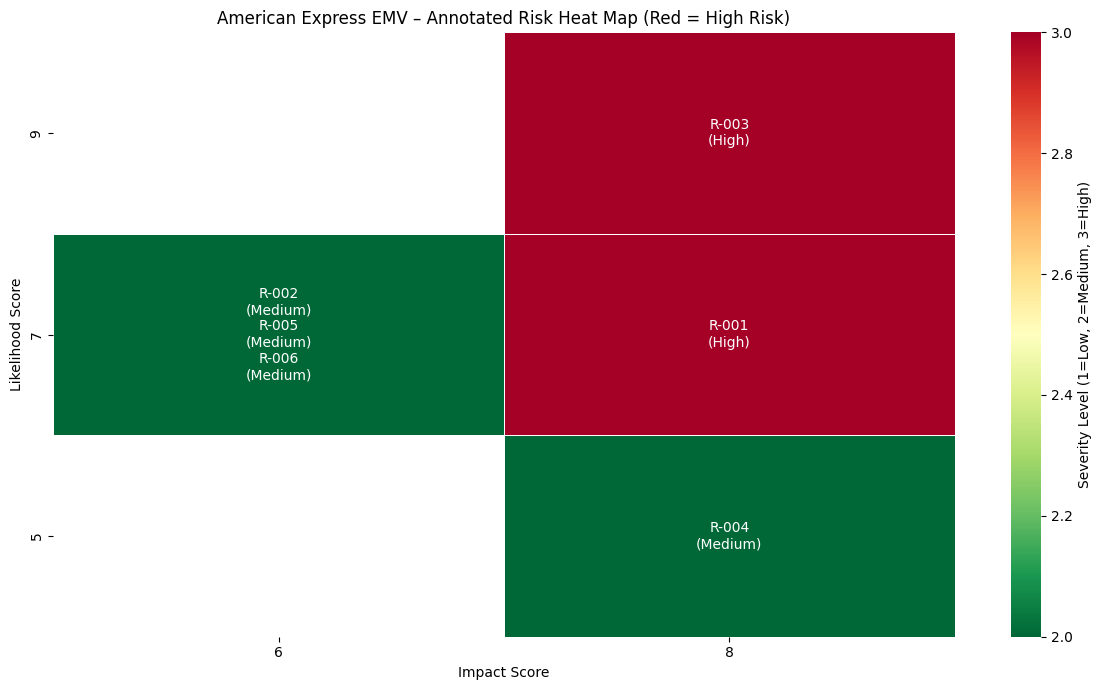

In [ ]:
# ============================================================
# Section 11
# ============================================================
# ### Step 6 — Annotated Risk Heat Map
#
# The heat map plots all 6 risks on a color-coded grid where:
# - X axis = Impact Score  (uses exact values: 1, 2, 4, 6, 8, 9)
# - Y axis = Likelihood Score (uses exact values: 1, 3, 5, 7, 9)
#
# Each cell is colored based on risk severity:
# Red = High, Yellow = Medium, Green = Low
# Each risk is labeled with its ID and severity level.


# ============================================================
# Section 12 — Heat map
# ============================================================

severity_map = df.copy()
severity_levels = {'Low': 1, 'Medium': 2, 'High': 3}
severity_map['Severity_Num'] = severity_map['Severity'].map(severity_levels)
severity_map['Label'] = severity_map['Risk #'] + '\n(' + severity_map['Severity'] + ')'

pivot_severity = severity_map.groupby(
    ['Likelihood Score', 'Impact Score'])['Severity_Num'].max().unstack()
pivot_severity = pivot_severity.sort_index(ascending=False)
pivot_severity = pivot_severity[pivot_severity.columns.sort_values()]

label_matrix = severity_map.groupby(
    ['Likelihood Score', 'Impact Score'])['Label'].apply(
        lambda x: '\n'.join(x)).unstack(fill_value='')
label_matrix = label_matrix.sort_index(ascending=False)
label_matrix = label_matrix[label_matrix.columns.sort_values()]

plt.figure(figsize=(12, 7))
sns.heatmap(pivot_severity, annot=label_matrix, fmt='', cmap='RdYlGn_r',
            linewidths=0.5,
            cbar_kws={'label': 'Severity Level (1=Low, 2=Medium, 3=High)'})
plt.title("American Express EMV – Annotated Risk Heat Map (Red = High Risk)")
plt.xlabel("Impact Score")
plt.ylabel("Likelihood Score")
plt.tight_layout()
plt.show()








  Step 7 — Confusion Matrix Plot

 The confusion matrix visually shows how well the Random Forest
 model predicted each severity class across the cross-validation folds.
 Darker blue cells along the diagonal indicate correct predictions.

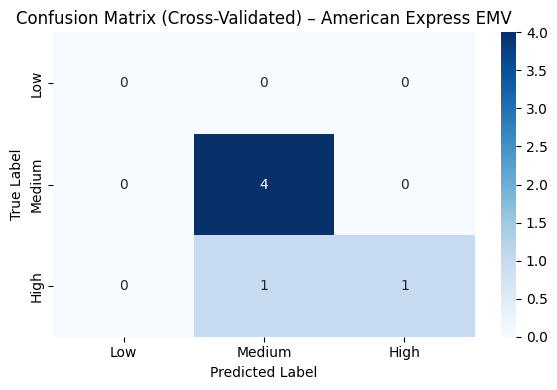

In [ ]:



# ============================================================
# Section 14 — Confusion matrix
# ============================================================

conf_matrix = confusion_matrix(y, y_pred_cv, labels=['Low', 'Medium', 'High'])

plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low', 'Medium', 'High'],
            yticklabels=['Low', 'Medium', 'High'])
plt.title("Confusion Matrix (Cross-Validated) – American Express EMV")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()


  Interpretation

 The heat map plots all 6 American Express EMV risks on a
 color-coded grid based on their Likelihood and Impact scores.

 **High Risk (Red Zone — Score 54–81):**
 - R-001 (Financial): CNP fraud losses scored 56. As EMV secured
   in-store transactions, fraudsters shifted to unprotected online
   channels, creating a major financial threat for Amex.
 - R-003 (Competitive): Merchant acceptance loss scored 72 —
  the highest risk. Visa and Mastercard's faster open-loop
   deployment gave them a significant competitive advantage.

 **Medium Risk (Yellow Zone — Score 27–53):**
- R-002, R-004, R-005, R-006 all fall in the medium range,
   requiring monitoring and mitigation but not immediate escalation.


 **Model Note:**
 The Random Forest classifier predicts severity based on Likelihood
 and Impact scores. Due to the small dataset size, results should be
 interpreted with caution. A larger, balanced dataset would improve
accuracy across all severity classes.

## Quantitative analysis
## Monte Carlo simulation

Quantitative Risk Assessment
 American Express EMV Chip Transition

 Following the qualitative risk register analysis,
 we now apply quantitative methods to assess the three priority risks.

 We use:
 1. Probability and Expected Impact calculations
 2. Monte Carlo Simulation to model the range of possible risk outcomes


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# Risk register baseline
data = {
    'Risk #':           ['R-001', 'R-002', 'R-003', 'R-004', 'R-005', 'R-006'],
    'Risk Type':        ['Financial', 'Operational', 'Competitive',
                         'Reputational', 'Legal/Compliance', 'Operational'],
    'Likelihood Score': [7, 7, 9, 5, 7, 7],
    'Impact Score':     [8, 6, 8, 8, 6, 6],
    'Risk Score':       [56, 42, 72, 40, 42, 42]
}

df = pd.DataFrame(data)

# Calculate Probability and Expected Impact
df['Probability (%)'] = round((df['Likelihood Score'] / 9) * 100, 2)
df['Expected Impact'] = round((df['Likelihood Score'] / 9) * (df['Impact Score'] / 9), 4)

print("=== PROBABILITY AND EXPECTED IMPACT ===\n")
print(df[['Risk #', 'Risk Type', 'Likelihood Score',
          'Impact Score', 'Probability (%)', 'Expected Impact']].to_string(index=False))


=== PROBABILITY AND EXPECTED IMPACT ===

Risk #        Risk Type  Likelihood Score  Impact Score  Probability (%)  Expected Impact
 R-001        Financial                 7             8            77.78           0.6914
 R-002      Operational                 7             6            77.78           0.5185
 R-003      Competitive                 9             8           100.00           0.8889
 R-004     Reputational                 5             8            55.56           0.4938
 R-005 Legal/Compliance                 7             6            77.78           0.5185
 R-006      Operational                 7             6            77.78           0.5185


Monte Carlo simulation runs 10,000 random scenarios for each risk.
Instead of relying on a single fixed risk score, it shows the full
 range of possible outcomes based on the probability and impact values
 we already calculated from the risk register.


In [2]:
np.random.seed(42)
n_simulations = 10000

# Use only the 3 priority risks
priority_risks = df[df['Risk #'].isin(['R-001', 'R-002', 'R-003'])].copy()

mc_results = {}

for _, row in priority_risks.iterrows():
    prob  = row['Likelihood Score'] / 9
    impact = row['Impact Score'] / 9

    # Simulate random variation around known probability and impact
    prob_samples   = np.random.normal(prob, 0.05, n_simulations).clip(0, 1)
    impact_samples = np.random.normal(impact, 0.05, n_simulations).clip(0, 1)

    # Scale back to 1-81 risk score range
    simulated_scores = prob_samples * impact_samples * 81

    mc_results[row['Risk #']] = {
        'Risk Type':       row['Risk Type'],
        'Scores':          simulated_scores,
        'Mean':            round(np.mean(simulated_scores), 2),
        'Median':          round(np.median(simulated_scores), 2),
        'Best Case (5%)':  round(np.percentile(simulated_scores, 5), 2),
        'Worst Case (95%)':round(np.percentile(simulated_scores, 95), 2)
    }



In [3]:
# Print summary
print("=== MONTE CARLO SIMULATION RESULTS (10,000 runs) ===\n")
for risk, res in mc_results.items():
    print(f"{risk} — {res['Risk Type']}")
    print(f"  Mean Score:        {res['Mean']}")
    print(f"  Median Score:      {res['Median']}")
    print(f"  Best Case  (5%):   {res['Best Case (5%)']}")
    print(f"  Worst Case (95%):  {res['Worst Case (95%)']}\n")


=== MONTE CARLO SIMULATION RESULTS (10,000 runs) ===

R-001 — Financial
  Mean Score:        56.02
  Median Score:      55.91
  Best Case  (5%):   48.39
  Worst Case (95%):  64.03

R-002 — Operational
  Mean Score:        41.94
  Median Score:      41.87
  Best Case  (5%):   35.28
  Worst Case (95%):  48.93

R-003 — Competitive
  Mean Score:        70.56
  Median Score:      70.62
  Best Case  (5%):   63.08
  Worst Case (95%):  77.81



Monte Carlo Distribution Charts

 - Each chart shows the spread of 10,000 simulated risk scores.
 - The blue line marks the average score.
 - The red line marks the worst case (95th percentile).

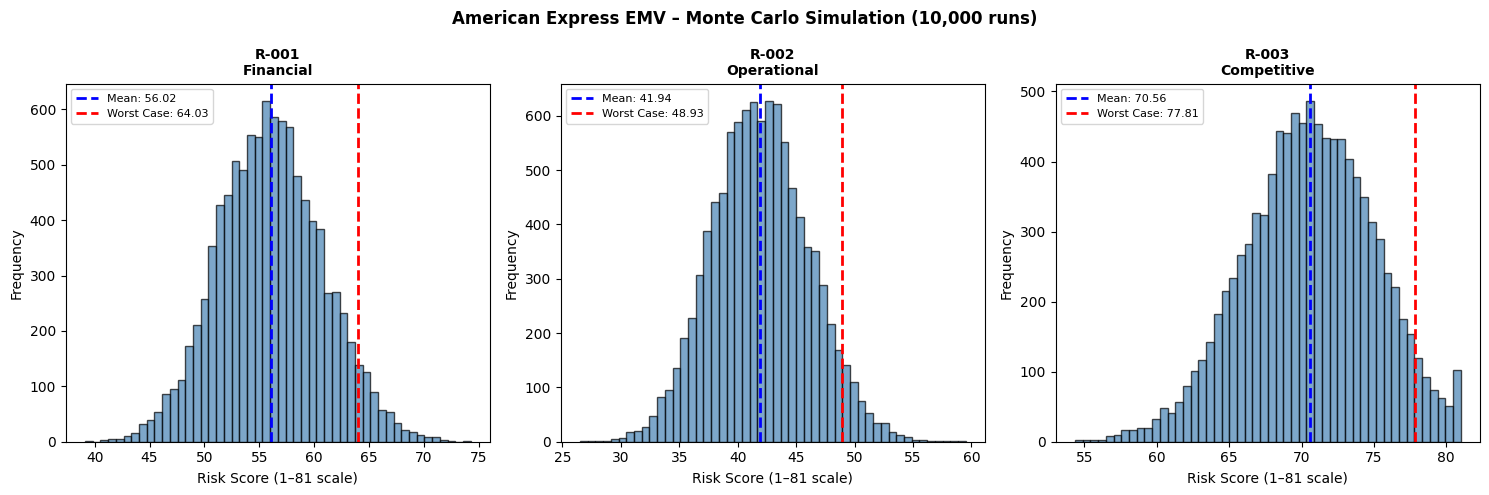

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (risk, res) in zip(axes, mc_results.items()):
    ax.hist(res['Scores'], bins=50, color='steelblue', alpha=0.7, edgecolor='black')
    ax.axvline(res['Mean'], color='blue', linestyle='--',
               linewidth=2, label=f"Mean: {res['Mean']}")
    ax.axvline(res['Worst Case (95%)'], color='red', linestyle='--',
               linewidth=2, label=f"Worst Case: {res['Worst Case (95%)']}")
    ax.set_title(f"{risk}\n{res['Risk Type']}", fontsize=10, fontweight='bold')
    ax.set_xlabel('Risk Score (1–81 scale)')
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=8)

plt.suptitle('American Express EMV – Monte Carlo Simulation (10,000 runs)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()